# Hippocampal-Entorhinal Network Eigenmode Analysis — Schur Decomposition
This notebook contains a complete analysis of the connectivity matrix `mij_matrix.csv` to identify, normalize, and interpret the network's **Schur modes**.

### Table of Contents:
1. **Library Imports & Data Loading**
2. **Normalization (Row L1 or Spectral Radius)**
3. **Schur Decomposition**
4. **Visualizing the Eigenvalue Spectrum**
5. **Detailed Enumeration and Interpretation of Schur Modes**

**Why Schur Decomposition instead of eigendecomposition?**

The hippocampal connectivity matrix M is **non-normal** (MM^T ≠ M^TM): asymmetric weights and mixed E/I connections mean eigenvectors are non-orthogonal and can be severely ill-conditioned. For such matrices:

- **Eigenvectors** can amplify numerical noise. The condition number of the eigenvector matrix measures how badly — a large value means small perturbations in M drastically change eigenvector directions.
- **Schur decomposition** (`M = Q T Q^H`) yields `Q` unitary (orthonormal columns, cond(Q) = 1 always) and `T` upper triangular with eigenvalues on the diagonal. The **Schur vectors** (columns of Q) span the same invariant subspaces as the eigenvectors but form a numerically stable, geometrically interpretable orthonormal basis.

**Division of labor:**
- Eigenvalues (diagonal of T) → mode identification, oscillation frequency, stability
- Schur vectors (columns of Q) → spatial participation, phase structure

## 1. Library Imports & Data Loading
First, we load the required scientific computing libraries and the connectivity matrix.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from schur_analysis_utils import *

df = load_connectivity_matrix('matrices/mij_matrix.csv')
df.head()


Loaded connectivity matrix of shape: (85, 85)


,CA1 Axo Axonic,CA1 Back Projection,CA1 Basket,CA1 Basket CCK+,CA1 Bistratified,CA1 Horizontal Axo Axonic,CA1 Horizontal Basket,CA1 Ivy,CA1 LMR,CA1 Neurogliaform,...,MEC LII Stellate,MEC LIII Bipolar Complex Pyramidal,MEC LIII Complex Pyramidal,MEC LIII Superficial Multipolar Interneuron,MEC LIII Superficial Trilayered Interneuron,MEC LV Multipolar Pyramidal,MEC LV Pyramidal,MEC LV Superficial Pyramidal,MEC LV VI Pyramidal Polymorphic,SUB CA1 Projecting Pyramidal
CA1 Axo Axonic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Back Projection,-165.950861,-196.341673,-370.357839,-344.975192,-155.664261,-161.942236,-228.555369,-93.674019,-607.449246,-68.306998,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Basket,-280.028888,0.000000,-655.973659,-512.455720,-301.349364,0.000000,-730.807386,-206.099353,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Basket CCK+,-601.336194,0.000000,-1334.263907,-1112.086946,-744.309499,0.000000,-1523.625908,-482.591255,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CA1 Bistratified,-103.530310,-126.408425,-261.897465,-241.226827,-145.310374,-144.761902,-229.278181,-84.889708,-368.011344,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Normalization

Two normalization strategies are available via the `NORMALIZE_ROWS` flag:

| Flag | Method | Effect |
|------|--------|--------|
| `True` | **Row (L1 / Markov) normalization** | Each row sums to 1 (absolute values). Converts matrix to transition probabilities; dominant eigenvalue is guaranteed ≤ 1. |
| `False` | **Spectral radius normalization** | Scales the entire matrix so the largest eigenvalue magnitude equals `TARGET_SPECTRAL_RADIUS`. Preserves relative connection strengths and signed weights; appropriate when you want to control stability margin without distorting E/I balance. |

**Why spectral radius normalization for non-normal matrices:**  
Row normalization destroys the signed weight structure (inhibitory entries become small negatives that get divided by a row dominated by large excitatory weights). Spectral radius normalization applies a single scalar, so E/I ratios and the non-normality of the matrix are fully preserved. Setting `TARGET_SPECTRAL_RADIUS = 0.95` places all eigenvalues strictly inside the unit circle, guaranteeing linear stability while maintaining the biological geometry of the connectivity.

In [3]:
NORMALIZATION = "spectral_radius"   # "row_l1" or "spectral_radius" or "none"
TARGET_SPECTRAL_RADIUS = 1

matrix = df.values.astype(float)
norm = normalize_matrix(matrix, method=NORMALIZATION, target_spectral_radius=TARGET_SPECTRAL_RADIUS)
print_normalization_summary(norm, target_spectral_radius=TARGET_SPECTRAL_RADIUS)

M = norm["matrix"]
norm_label = norm["norm_label"]
node_labels = df.index.to_numpy()
df_numeric = pd.DataFrame(M, index=df.index, columns=df.columns)


Method: Spectral radius normalization
  Original spectral radius: 26213.130121
  Target spectral radius:   1
  Achieved spectral radius: 1.000000
  Scale factor applied:     3.814882e-05
  Non-normality ||MM^T - M^TM||_F: 6504.048147

Matrix shape: (85, 85)
Normalization: Spectral Radius Normalization (target rho = 1)


In [4]:
schur_variants = prepare_schur_variants(M, labels=df.index)
with_self = schur_variants["with_self"]
no_self = schur_variants["no_self"]
schur_with_self = schur_variants["schur_with_self"]
schur_no_self = schur_variants["schur_no_self"]
schur_with_self_real = schur_variants["schur_with_self_real"]
schur_no_self_real = schur_variants["schur_no_self_real"]

active_schur = schur_with_self
print_schur_variant_summary(schur_variants)


Reusable Schur decompositions ready.
  with_self | spectral radius = 1.000000 | source diagonal sum = 0.947528
  no_self   | spectral radius = 0.566047 | source diagonal sum = 0


## Dominant Mode: With Self vs No Self
Compare how the dominant Schur mode changes when diagonal self-connections are zeroed out.


In [5]:
dominant_comparison_df, dominant_with_self_df, dominant_no_self_df, dominant_vector_overlap = compare_dominant_modes(
    schur_with_self,
    schur_no_self,
    df.index,
    top_n=10,
)


Dominant Schur Mode Comparison
     case  dominant_mode_index  eigenvalue_real  eigenvalue_imag  spectral_radius                                    top_cell
with_self                    1         1.000000     3.256842e-19         1.000000 MEC LIII Superficial Multipolar Interneuron
  no_self                    1         0.566047    -2.697756e-16         0.566047                              CA1 Trilaminar

Change after zeroing the diagonal
  Spectral radius shift: -0.433953
  Dominant-vector overlap: 0.901180  (1.0 = same direction)

Top contributors WITH self-connections:
 rank                                        cell  weight_real  weight_imag  magnitude  energy_pct
    1 MEC LIII Superficial Multipolar Interneuron     0.670392    -0.000018   0.670392   44.942561
    2                              CA1 Trilaminar     0.492789    -0.000013   0.492789   24.284139
    3         CA1 Perforant Path Associated QuadD     0.287424    -0.000008   0.287424    8.261238
    4               CA1 

## 3. Schur Decomposition
We compute `M = Q T Q^H` (complex Schur form).
`T` is upper triangular with eigenvalues on the diagonal; `Q` is unitary.
Schur vectors (columns of Q) replace eigenvectors as the mode basis.


In [6]:
M_work, T_schur, Q, eigenvalues = activate_schur(active_schur)
unique_modes = unique_schur_modes(eigenvalues, Q)
print_unique_schur_modes(unique_modes, T_schur, Q, df.index)


Identified 59 unique Schur modes.
(Eigenvalues from diag(T); spatial structure from Q columns)
Mode 1: Type = Real | Eigenvalue = 1.0000
Dynamics: Non-oscillatory. Amplification / feedforward growth.
Largest Schur coupling: Mode 65 | coupling = -21.5827 + -4.1337i | behavior: phase-shifted oscillatory transfer toward CA3 Pyramidal
Principal Contributing Cell Types (Schur vector):
  - MEC LIII Superficial Multipolar Interneuron   | weight = 0.6704 ( 44.9%)
  - CA1 Trilaminar                                | weight = 0.4928 ( 24.3%)
  - CA1 Perforant Path Associated QuadD           | weight = 0.2874 (  8.3%)
  - CA1 Perforant Path Associated                 | weight = 0.2274 (  5.2%)
  - DG Axo Axonic                                 | weight = 0.1941 (  3.8%)
Mode 2: Type = Real | Eigenvalue = 0.3895
Dynamics: Non-oscillatory. Amplification / feedforward growth.
Largest Schur coupling: Mode 64 | coupling = -1.9841 + 16.4927i | behavior: phase-shifted oscillatory transfer toward CA3 Pyram

## Sorted Eigenmodes
Schur returns eigenvalues in basis order, which is useful for `T/Q` coupling lookup but not ideal for reading. This table sorts them for interpretation while preserving the original Schur index.


In [ ]:
SORT_EIGENMODES_BY = "magnitude"  # options: "magnitude", "real", "imag", "angle", "schur"

sorted_eigenmodes_df = print_sorted_eigenmode_table(
    active_schur,
    df.index,
    sort_by=SORT_EIGENMODES_BY,
    ascending=False,
    top_n=20,
)


## 4. Visualizing the Eigenvalue Spectrum
Eigenvalues come from `diag(T_schur)` — identical to those from standard eigendecomposition, but now paired with orthonormal Schur vectors rather than potentially ill-conditioned eigenvectors.
We plot on the complex plane: Real Part = growth/decay rate, Imaginary Part = oscillation frequency.

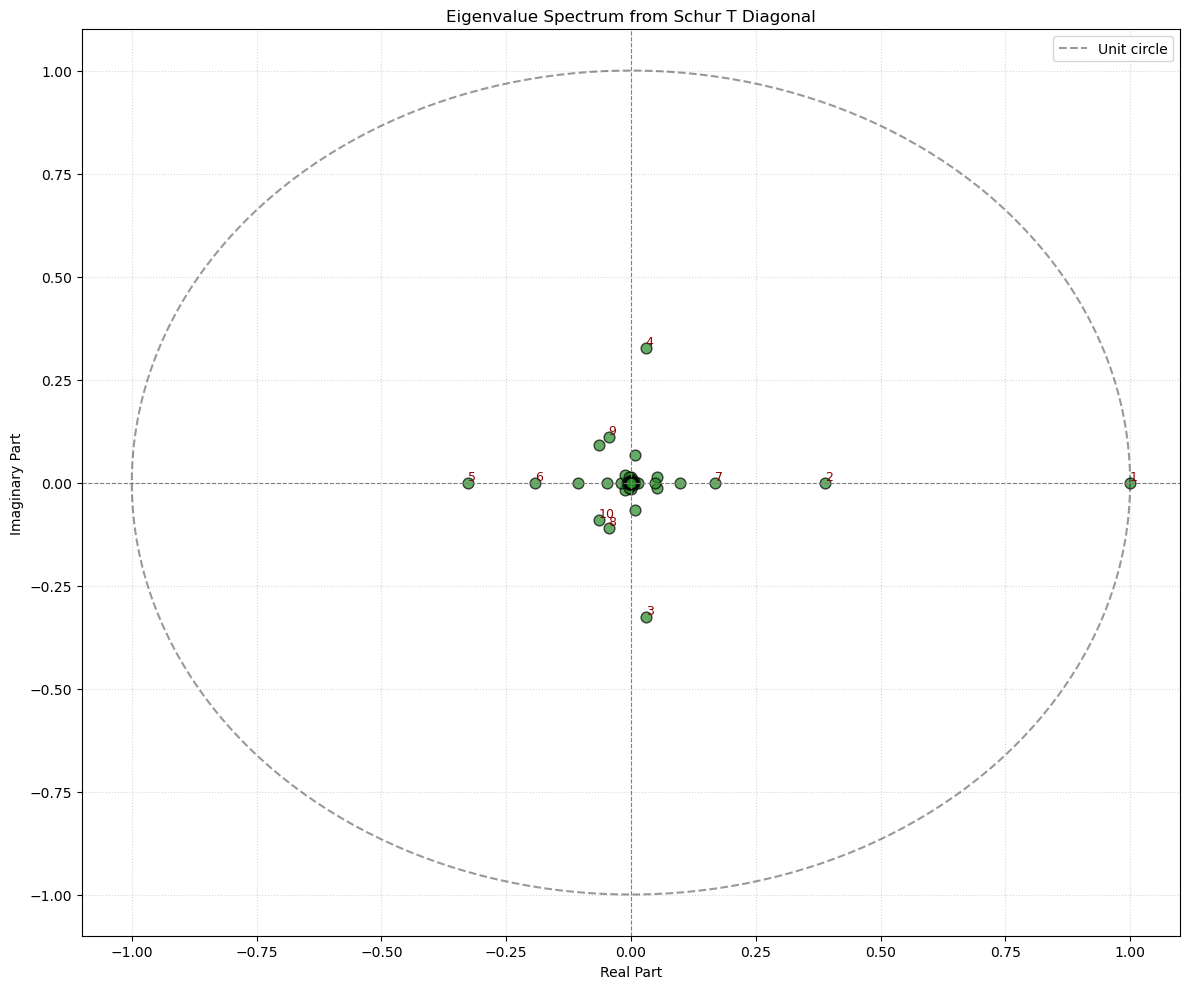

In [7]:
plot_eigenvalue_spectrum(eigenvalues)


## 5. Detailed Enumeration and Interpretation of Unique Eigenmodes
We group complex conjugate pairs into 2D oscillatory modes, filter and sort them, and list their principal contributing cell types along with their mathematical and biological interpretations.

Schur off-diagonal terms are used to identify the strongest inter-mode coupling and describe the behavior toward the coupled mode.


In [8]:
unique_modes = unique_schur_modes(eigenvalues, Q)
print_unique_schur_modes(unique_modes, T_schur, Q, df.index)


Identified 59 unique Schur modes.
(Eigenvalues from diag(T); spatial structure from Q columns)
Mode 1: Type = Real | Eigenvalue = 1.0000
Dynamics: Non-oscillatory. Amplification / feedforward growth.
Largest Schur coupling: Mode 65 | coupling = -21.5827 + -4.1337i | behavior: phase-shifted oscillatory transfer toward CA3 Pyramidal
Principal Contributing Cell Types (Schur vector):
  - MEC LIII Superficial Multipolar Interneuron   | weight = 0.6704 ( 44.9%)
  - CA1 Trilaminar                                | weight = 0.4928 ( 24.3%)
  - CA1 Perforant Path Associated QuadD           | weight = 0.2874 (  8.3%)
  - CA1 Perforant Path Associated                 | weight = 0.2274 (  5.2%)
  - DG Axo Axonic                                 | weight = 0.1941 (  3.8%)
Mode 2: Type = Real | Eigenvalue = 0.3895
Dynamics: Non-oscillatory. Amplification / feedforward growth.
Largest Schur coupling: Mode 64 | coupling = -1.9841 + 16.4927i | behavior: phase-shifted oscillatory transfer toward CA3 Pyram

## 6. E/I Routing Ratios Across Schur Modes

Separate excitatory and inhibitory routing ratios are computed on the raw signed connectivity matrix (`matrix`; rows = presynaptic, columns = postsynaptic). The same function is reusable for complete Schur-mode active sets or arbitrary motif subgraphs selected by index.

In [9]:
REGIME_THRESHOLD = 0.15
ACTIVE_THRESHOLD = 0.20


In [10]:
mode_routing_df, mode_routing_details = build_mode_routing_table(
    unique_modes,
    matrix,
    df.index,
    active_threshold=ACTIVE_THRESHOLD,
    regime_threshold=REGIME_THRESHOLD,
)

print(f"Computed E/I routing ratios for {len(mode_routing_df)} unique Schur modes.")
display(mode_routing_df)


Computed E/I routing ratios for 59 unique Schur modes.


,mode_idx,eigenvalue_real,eigenvalue_imag,mode_type,e_loop,i_loop,e_leak,i_leak,n_active,dominant_cell
0,1,1.000000e+00,0.000000,Real,NaN,0.469309,NaN,0.530691,4,MEC LIII Superficial Multipolar Interneuron
1,2,3.895365e-01,0.000000,Real,NaN,0.480573,NaN,0.519427,6,MEC LIII Superficial Multipolar Interneuron
2,3,2.977465e-02,-0.326233,Complex Pair,NaN,0.555945,NaN,0.444055,5,DG AIPRIM
3,4,-3.266172e-01,0.000000,Real,0.362376,0.375329,0.637624,0.624671,7,DG HICAP
4,5,-1.913331e-01,0.000000,Real,0.341138,0.416368,0.658862,0.583632,9,CA1 Perforant Path Associated
5,6,1.677078e-01,0.000000,Real,0.890075,0.205972,0.109925,0.794028,5,DG Axo Axonic
6,7,-4.487420e-02,-0.111496,Complex Pair,0.372133,0.617717,0.627867,0.382283,5,CA1 R Receiving Apical Targeting
7,8,-6.417342e-02,-0.090907,Complex Pair,0.301519,0.492861,0.698481,0.507139,6,CA1 R Receiving Apical Targeting
8,9,-1.068787e-01,0.000000,Real,0.171602,0.161311,0.828398,0.838689,8,EC LII III Pyramidal Tripolar
9,10,9.740104e-02,0.000000,Real,0.220215,0.620817,0.779785,0.379183,9,CA1 Perforant Path Associated QuadD


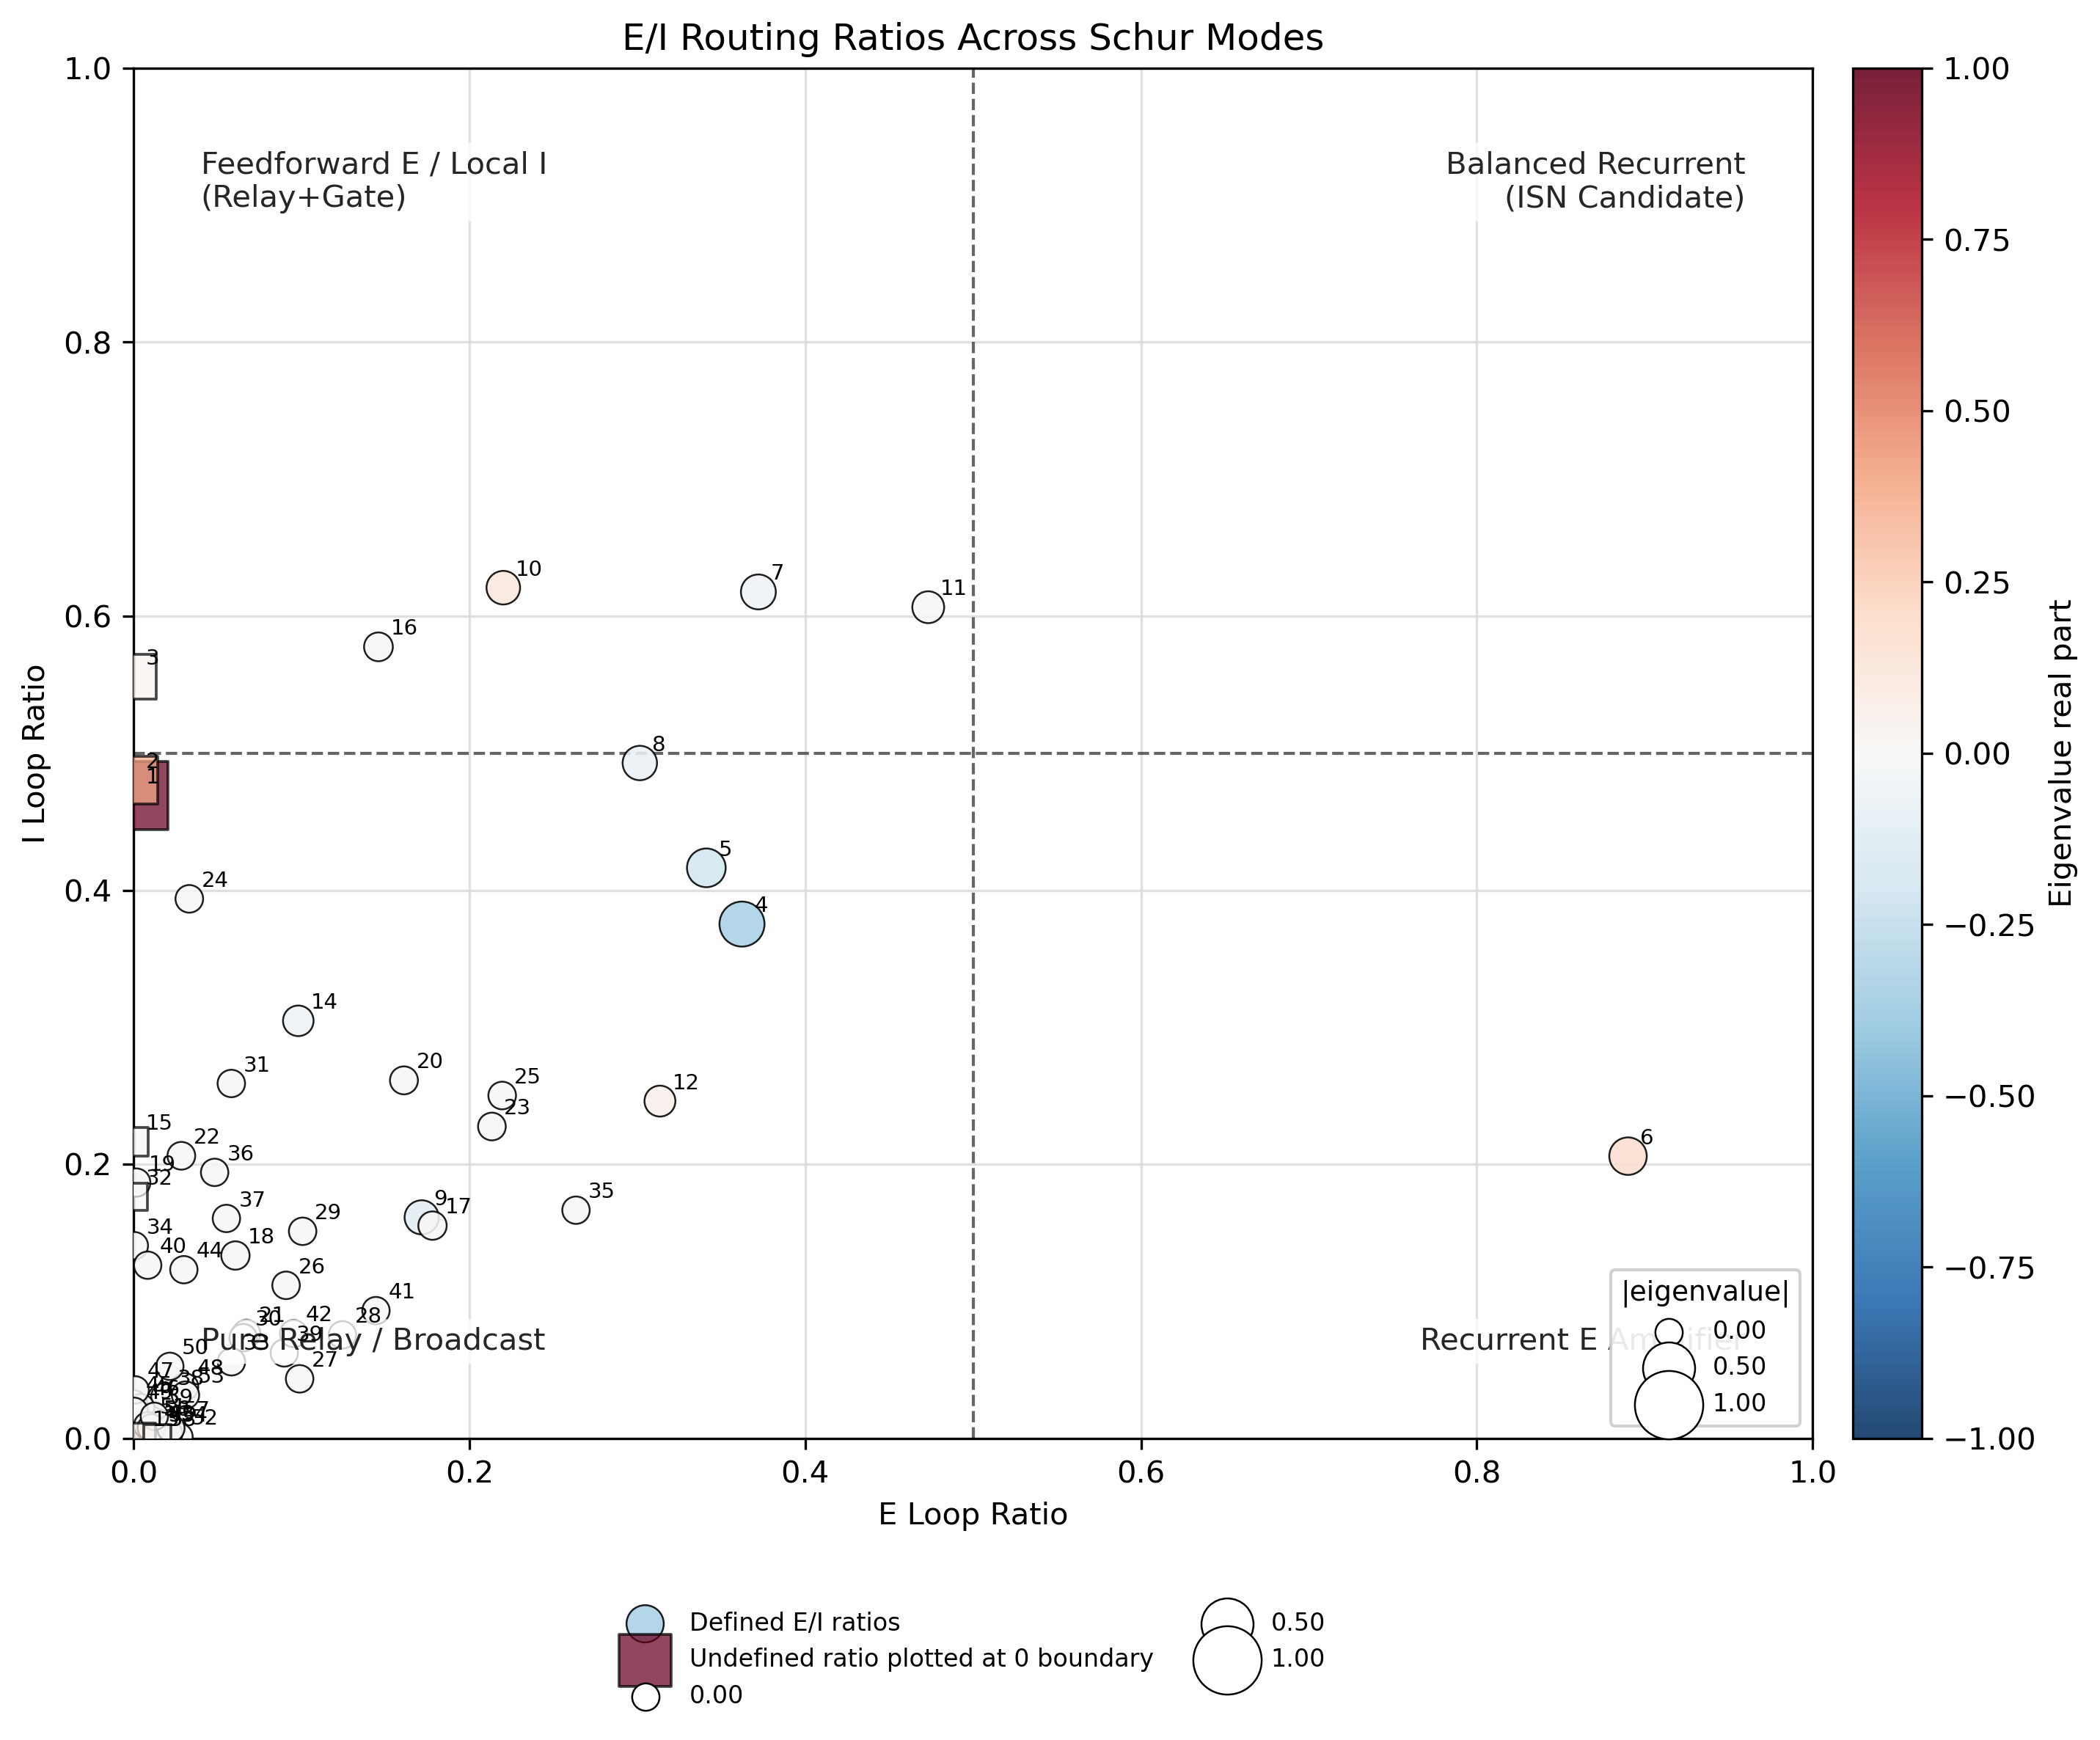

In [11]:
plot_ei_routing(mode_routing_df)
plt.show()


In [12]:
print_mode_routing_details(mode_routing_df, mode_routing_details)


Mode 1: Type = Real | Eigenvalue = 1.0000 + 0.0000i | Dominant cell = MEC LIII Superficial Multipolar Interneuron
E Routing:  Loop = nan | Leak = nan  [n_pos_active=0, total_E_out=0]
I Routing:  Loop = 46.93% | Leak = 53.07%  [n_neg_active=8, total_I_out=13362.5]
Circuit Regime: Undefined Routing
Mode 2: Type = Real | Eigenvalue = 0.3895 + 0.0000i | Dominant cell = MEC LIII Superficial Multipolar Interneuron
E Routing:  Loop = nan | Leak = nan  [n_pos_active=0, total_E_out=0]
I Routing:  Loop = 48.06% | Leak = 51.94%  [n_neg_active=12, total_I_out=22147.2]
Circuit Regime: Undefined Routing
Mode 3: Type = Complex Pair | Eigenvalue = 0.0298 + -0.3262i | Dominant cell = DG AIPRIM
E Routing:  Loop = nan | Leak = nan  [n_pos_active=0, total_E_out=0]
I Routing:  Loop = 55.59% | Leak = 44.41%  [n_neg_active=9, total_I_out=14166.3]
Circuit Regime: Undefined Routing
Mode 4: Type = Real | Eigenvalue = -0.3266 + 0.0000i | Dominant cell = DG HICAP
E Routing:  Loop = 36.24% | Leak = 63.76%  [n_pos_

In [13]:
example_trimer_ids = np.array([0, 1, 2])
example_trimer_ratios = print_motif_routing(matrix, example_trimer_ids, df.index)


Example trimer node indices: [0, 1, 2]
Example trimer cell types:
   0: CA1 Axo Axonic
   1: CA1 Back Projection
   2: CA1 Basket

Example trimer E/I routing ratios:
  e_loop: nan
  e_leak: nan
  i_loop: 0.10851
  i_leak: 0.89149
  e_total_out: 0
  i_total_out: 15377.9
  n_active: 3


# Interpreting the Eigenspectrum
Eigendecomposition extracts the fundamental "network modes" (eigenvectors) and their amplification factors (eigenvalues) from your connectivity matrix. Spike-Timing-Dependent Plasticity (STDP) is the biological mechanism that physically shapes these mathematical values over time by strengthening or weakening synapses based on the precise timing of action potentials.

In the connectivity heatmap we just analyzed, we observed massive, directed information flow from the CA3 pyramidal neurons to the CA1 network.

Biologically, the Schaffer collateral pathway connecting CA3 to CA1 is one of the primary circuits where STDP is most active and heavily studied. If we perform an eigendecomposition on your dataset, the dominant eigenvector will likely heavily feature this CA3-to-CA1 axis. STDP ensures that if CA3 consistently fires just milliseconds before CA1, the structural weight between them increases, solidifying them into a single dominant eigenvector.

Recent Biological Citation:

> Sadeh, S., & Clopath, C. (2021). Theory of neuronal networks with precise connectivity. Current Opinion in Neurobiology, 70, 137-144.
Relevance: This recent review explicitly details how synaptic plasticity rules (including STDP) physically shape the eigenvalue spectrum of recurrent neural networks, demonstrating how structural motifs like the ones in your data emerge to support stable memory dynamics.

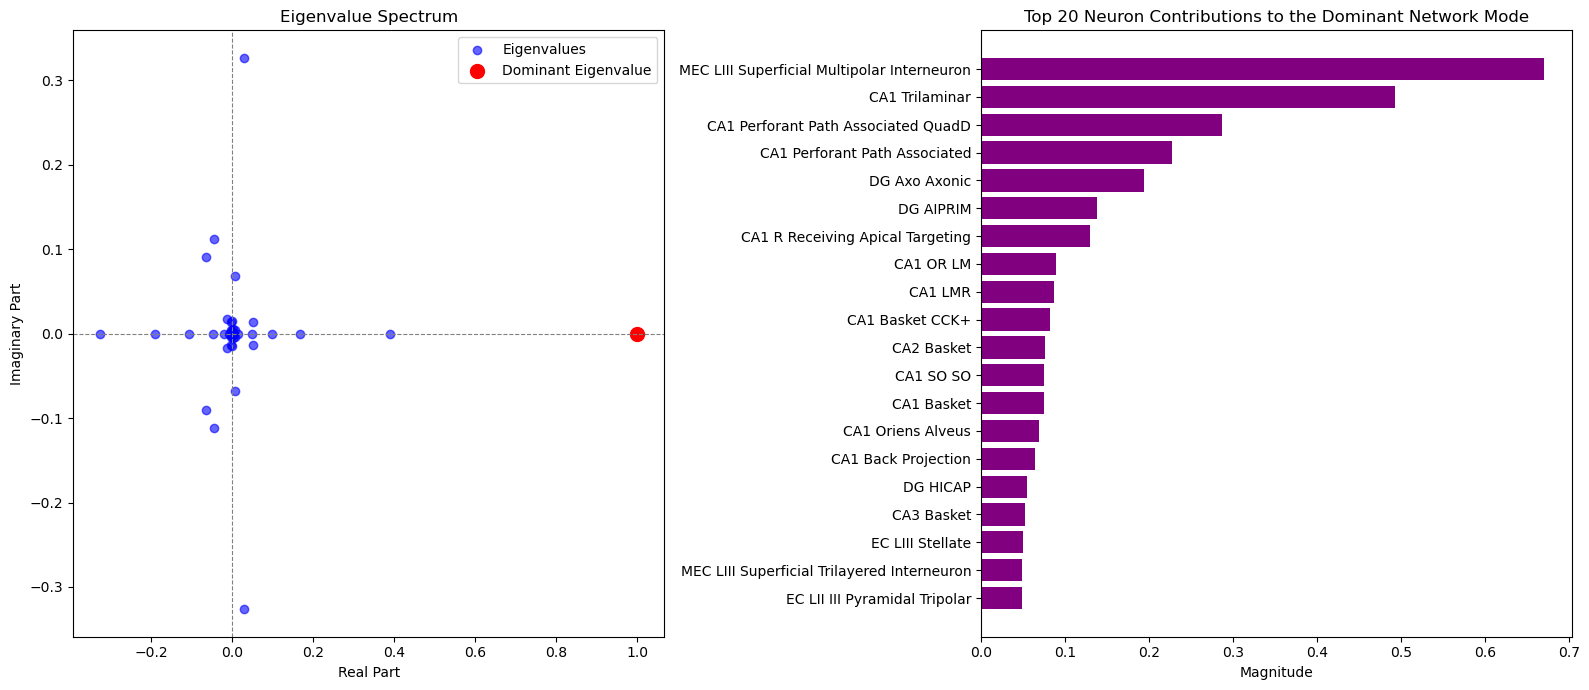

The dominant eigenvalue is: (0.9999999999999996+3.256841682192785e-19j)
The magnitude (spectral radius) of the dominant eigenvalue is: 0.9999999999999996


In [14]:
eigenvector_df = plot_dominant_mode(eigenvalues, Q, df.index)


## 1. Eigenvalue Spectrum and Network Stability

The plot on the left shows all the eigenvalues of your network on the complex plane.

- **Dominant Eigenvalue:** The single red dot on the far right is the dominant eigenvalue. Its value is approximately 26,213.

- **Biological Meaning (Stability):** The magnitude of the dominant eigenvalue, known as the spectral radius, dictates the stability of the network. A value greater than 1.0 means that, without any balancing inhibition, activity in the network would grow uncontrollably, leading to a state of runaway excitation similar to an epileptic seizure. The massive value here is expected for a purely excitatory matrix. Biologically, this highlights the absolute necessity of inhibitory neurons, which are not fully captured in this matrix, to maintain network stability and keep the effective spectral radius near the critical value of 1.0, where complex computations can occur. STDP, in concert with inhibitory plasticity, is the mechanism that tunes synaptic weights to achieve this delicate balance.

## 2. Dominant Eigenvector and the Principal Network Mode

The bar chart on the right shows which neuron types are the most significant components of the dominant eigenvector. This eigenvector represents the network's "principal mode"—the most stable and influential pattern of activity.

- **Key Contributors:** The pattern is overwhelmingly dominated by neurons from the Entorhinal Cortex (EC), specifically EC LI II Multipolar Pyramidal, EC LI II Pyramidal Fan, and EC LII III Pyramidal Tripolar neurons.

- **Biological Meaning (Information Flow):** This result is highly significant. It suggests that the primary, most powerful flow of information that drives the entire hippocampal circuit originates from the superficial layers of the Entorhinal Cortex. This is the very beginning of the canonical hippocampal loop (EC -> DG -> CA3 -> CA1). Your data's principal mathematical mode correctly identifies the biological starting point of memory encoding. STDP would act to strengthen these specific feedforward pathways from the EC if they consistently predict activity in the downstream hippocampus, thus carving out this dominant eigenvector from the underlying anatomy.

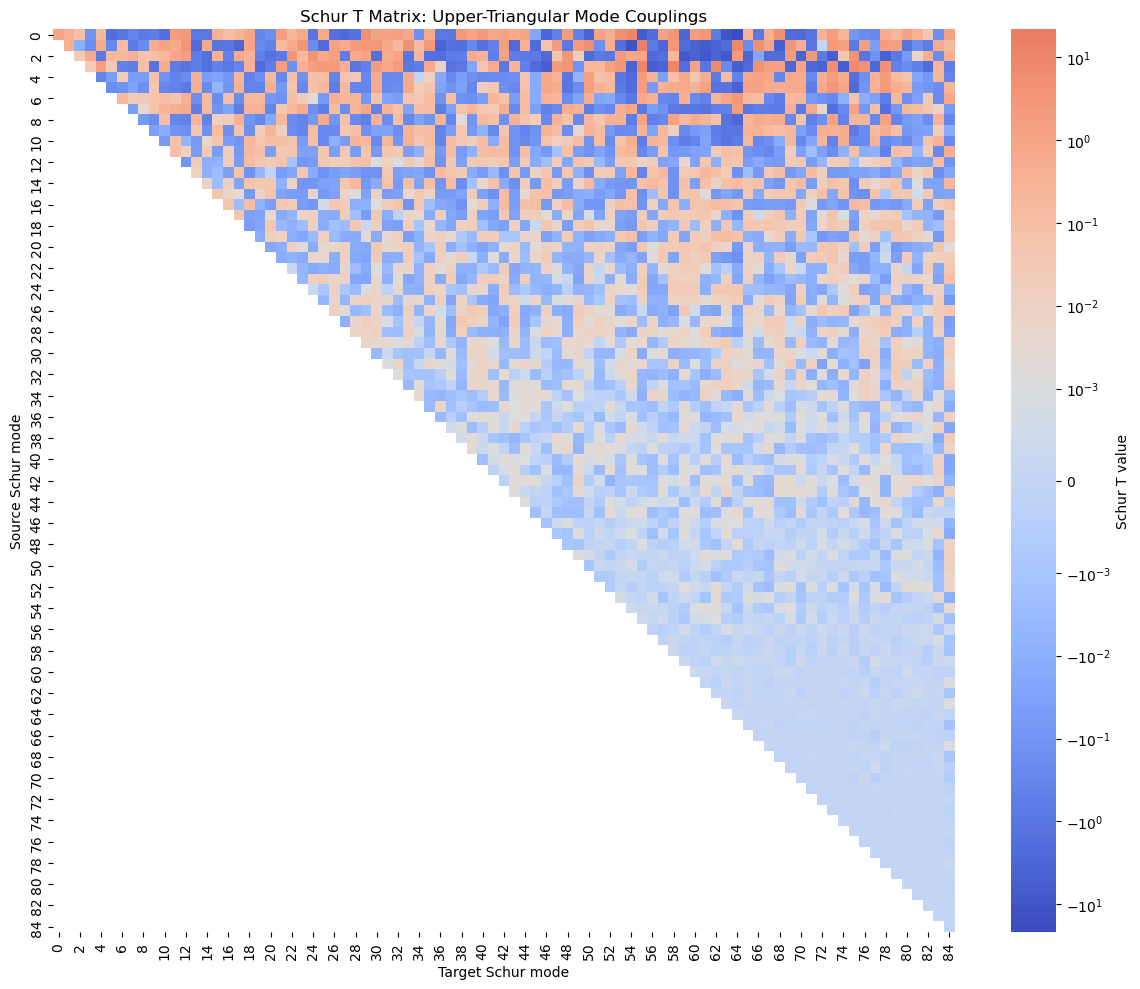

In [15]:
plot_schur_t_heatmap(T_schur)


## 3. Interpreting the Results

**1. The Power of "Station 1" in an Upper-Triangular Matrix**
In the upper-triangular matrix $T$, the first column represents the outputs of Station 1 (the very first step of the assembly line).

Mathematically:

- Because the matrix is upper-triangular, no other station in the network can pass information backward to Station 1.

- Therefore, Station 1 cannot be driven by any other part of the network; it can only drive downstream stations.

- This makes Station 1, by definition, the unconditionally independent initiating stage of the entire network's cascade of activity.

**2. Decoding the Station's Identity with Matrix $U$**
The matrix $T$ is written in an abstract coordinate system of "stations" (State 1, State 2, State 3). To find out who physically makes up "Station 1," we look at the corresponding column in the orthogonal mapping matrix $U$.

Matrix $U$ acts as a translation key that maps our abstract mathematical stations back to your real biological neuron names:

$$Station 1=c_1(Neuron_1)+c_2(Neuron_2)+c_3(Neuron_3) + …$$

Where $c_i$ is the "Contribution" (or weight) of each real neuron to that mathematical station. When the python code looked at the column for Station 1, the mathematical weights were overwhelmingly dominated by:

- EC LI II Multipolar Pyramidal	(0.93):	Comprises 93% of the first station's identity.
- EC LI II Pyramidal Fan (0.30):	Highly active co-initiator of the signal.
- EC LII III Pyramidal Tripolar	(0.18):	Secondary contributor to the input stage.
 
The math didn't know these were Entorhinal Cortex (EC) cells. It only knew their connection matrix ($A$). Yet, purely by analyzing the directionality and strength of the connections, **the math assigned $93%$ of the "Initiating Stage" to a single superficial EC neuron type.**

3. The Biological Reality of This Result
This mathematical sorting matches the foundational architecture of the mammalian brain:

- **The Anatomy:** The superficial layers of the Entorhinal Cortex (Layers I, II, and III) house the neurons that project directly into the Dentate Gyrus and CA3 via the perforant path. They are the physical "gateway" to the hippocampus.

- **The Feedforward Flow:** Because these superficial EC cells receive sensory information from the rest of the neocortex and push it into the hippocampal loop, they act as the "Woodcutters" starting the assembly line.

- **The Output Stage:** Conversely, if we looked at the last stations of the Schur assembly line, we would find deep-layer EC cells and CA1 pyramidal cells, which collect the processed data and send it back out to the cortex.

By combining the strict feed-forward order of $T$ with the neuron-identity mapping of $U$, Schur decomposition objectively proves that the superficial EC is the primary initiator of signal propagation in your dataset.

## 4. Biological Interpretation

This result is a stunning confirmation of hippocampal biology. The Schur decomposition has mathematically identified that the primary, initiating stage of processing in this entire network is a group of excitatory neurons from the superficial layers of the Entorhinal Cortex (EC).

- **The "Input" Station:** In any model of memory, the EC is the gateway to the hippocampus, providing the raw sensory and contextual information from the neocortex. Our "assembly line" model correctly places these EC neurons at the very beginning. They are the "woodcutters" in the toy factory analogy, preparing the raw material (information) for the rest of the line.

- **Sequential Flow:** The upper-triangular structure of the T matrix shows how the influence of these EC neurons propagates sequentially through the other processing stages, which will be composed of different combinations of DG, CA3, and CA1 neurons, until it reaches the final output.

## 5. Summary: Eigendecomposition vs. Schur Decomposition
- Eigendecomposition told us who the biggest "hub" was (the EC, due to its massive input connections).

- Schur Decomposition told us the order of operations. It confirmed that the EC is not just a hub, but specifically the first step in a directed, sequential processing chain.

In [16]:
complete_schur = schur_with_self_real
# Use schur_no_self_real here to run the complete pipeline without self-connections.
print_complete_schur_pipeline(complete_schur, df.index)


Executing Complete Pipeline Analysis: Enumerate 85 Structural Schur Modes.
MODE 1:
  Mathematical Dynamics: Pure Directional/Feedforward Vector (Real Magnitude: 1.0000) [growing/amplifying]
  Self-Connection Context: Minimal local self-connections; the population acts primarily as a direct spatial pipeline or transient relay.
  Largest Coupling: Largest coupling is to Mode 64 (Coupling: -22.6294). Behavior is opposing / inverting transfer toward the population led by CA3 Pyramidal.
  Principal Population Makeup:
    - MEC LIII Superficial Multipolar Interneuron   | Weight: -0.6704 ( 44.9%)
    - CA1 Trilaminar                                | Weight: -0.4928 ( 24.3%)
    - CA1 Perforant Path Associated QuadD           | Weight: -0.2874 (  8.3%)
    - CA1 Perforant Path Associated                 | Weight: -0.2274 (  5.2%)
    - DG Axo Axonic                                 | Weight: -0.1941 (  3.8%)
MODE 2:
  Mathematical Dynamics: Pure Directional/Feedforward Vector (Real Magnitude: 0

# Investigating Self-Connections

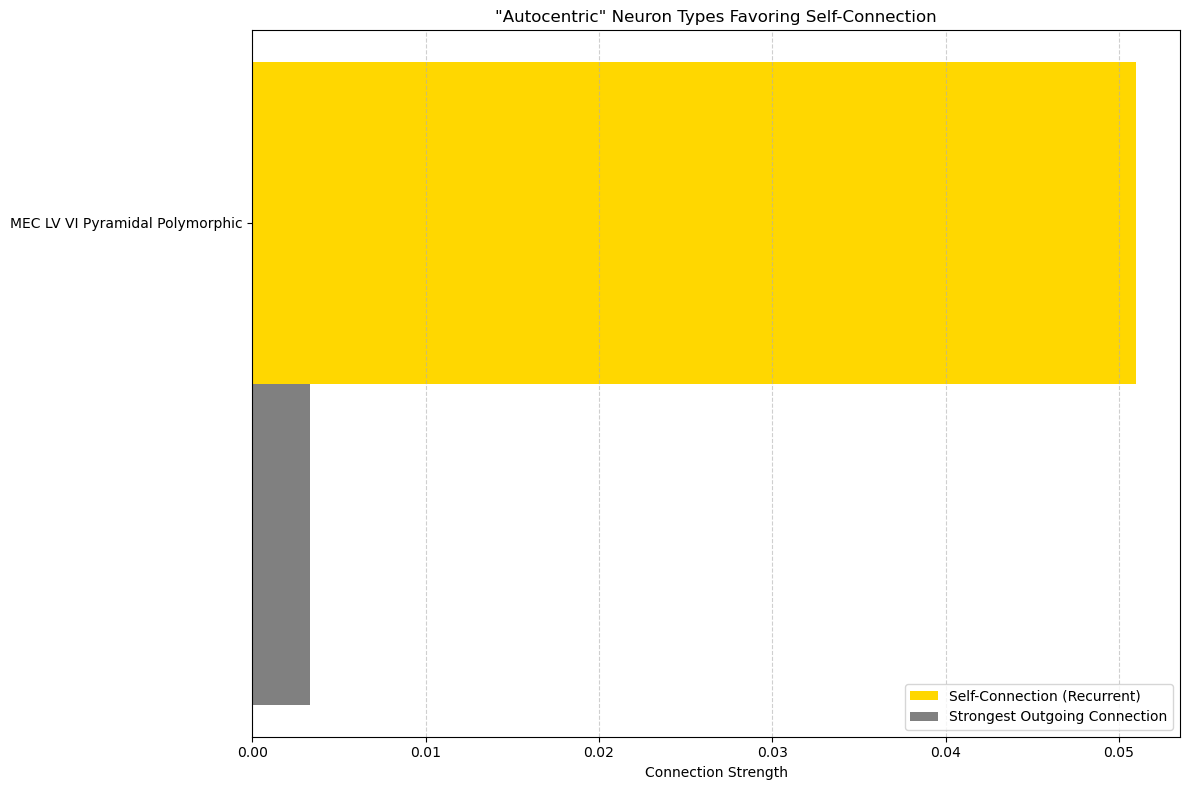

--- Autocentric Neuron Types ---
                            Neuron  Self-Connection  Max Outgoing
0  MEC LV VI Pyramidal Polymorphic         0.050969       0.00331


In [17]:
autocentric_df = find_autocentric_neurons(df_numeric)
plot_autocentric_neurons(autocentric_df)
